In [15]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
import mpemba
potential = mpemba.special_potentials.HarmonicPotential(E_0=10, x_min=-10, x_max=10)

In [2]:
# potential = mpemba.special_potentials.AsymmetricDoubleWellPotential(E_tilt=0.4, x_min=-5, x_max=5, force_asymmetry=0.5)

# x = potential.mesh(1000)
# y = potential.mesh(1000)[:, np.newaxis]
# dx = y[1,0]-y[0,0]
# dy = dx
# PDF = potential.boltzmann(x, 1)
# k = 100
# # quadratic_PDF = np.exp(-k*x_red**2/2)/np.sqrt(2*np.pi/k)
# PDF_convolved = (np.exp(-potential.U(y)-0.5*k*(x-y)**2)).sum(axis=0)*dy
# PDF_convolved /= PDF_convolved.sum()*dx
# plt.plot(x, PDF)
# plt.plot(x, PDF_convolved)
# # output = pd.DataFrame(np.array([x, PDF, PDF_convolved]).T, columns=['x','p','pconv'])
# # output.to_csv('flattened_PDFs.csv', index=None)

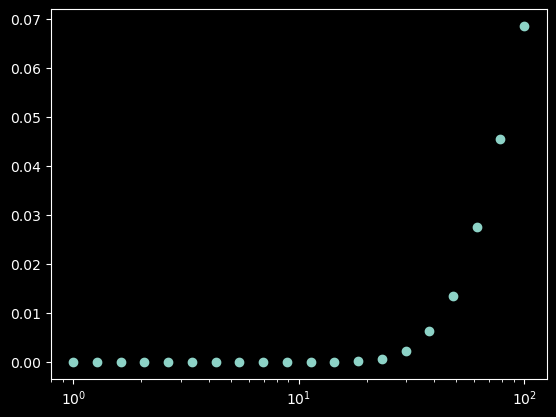

In [16]:
def clip_fraction(T_h, D=150, potential=potential, N_montecarlo=1_000_000):
    x_vals = np.linspace(potential.x_min, potential.x_max, N_montecarlo)
    pi_h = potential.boltzmann(x_vals, T_h)
    x_sampled = np.random.choice(x_vals, N_montecarlo, p=pi_h/np.sum(pi_h))
    F_sampled = potential.F(x_sampled)
    eta = np.random.normal(0,1, size=F_sampled.shape)*np.sqrt(2*(T_h-1)/D)
    noise_force_sampled = F_sampled + eta
    return ((np.abs(noise_force_sampled) > potential.F_left).sum())/len(noise_force_sampled)

clip_fractions = []
T_hs = np.logspace(0, np.log10(100), 20)
for T_h in T_hs:
    clip_fractions.append(clip_fraction(T_h, N_montecarlo=100_000))

plt.semilogx()
plt.scatter(T_hs, clip_fractions)
    

100%|██████████| 4999/4999 [00:02<00:00, 2300.79it/s]


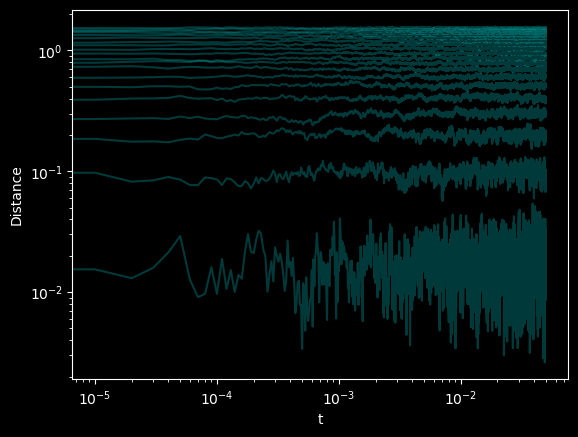

In [17]:
trivial_quench = mpemba.quench_methods.InfinitelySlowQuench()

def distance_difference(T_hs, D=150, potential=potential, num_particles=10_000, trivial_quench=trivial_quench, averaging_window=1000, clip_force=np.inf):
    ensemble = mpemba.construct_simulated_ensemble(potential, k_BTs=T_hs, num_particles=num_particles, gamma=1/D, expt_length=5e-2, quench_protocol=trivial_quench, clip_force=clip_force)
    distances = ensemble.get_distances()
    distances_0 = distances[:, 0]
    distances_f = distances[:,-averaging_window:].mean(axis=1)
    distances_std = distances[:, -averaging_window:].std(axis=1)
    ensemble.plot_distances(colors=['c']*len(T_hs//2), other_plt_kwargs={'alpha': 0.3})
    return distances_0, distances_f, distances_std, ensemble

k_BT_hs = np.logspace(0, np.log10(80), 20)
distances_0, distances_f, distances_std, ensemble = distance_difference(k_BT_hs, num_particles=5_000)

<ErrorbarContainer object of 3 artists>

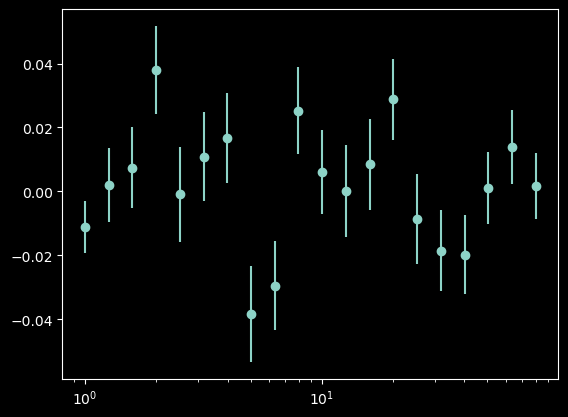

In [22]:
plt.semilogx()
plt.errorbar(k_BT_hs, distances_f-distances_0, yerr=distances_std, fmt='o')
# plt.scatter(T_hs, distances_0)

100%|██████████| 4999/4999 [00:01<00:00, 2666.90it/s]


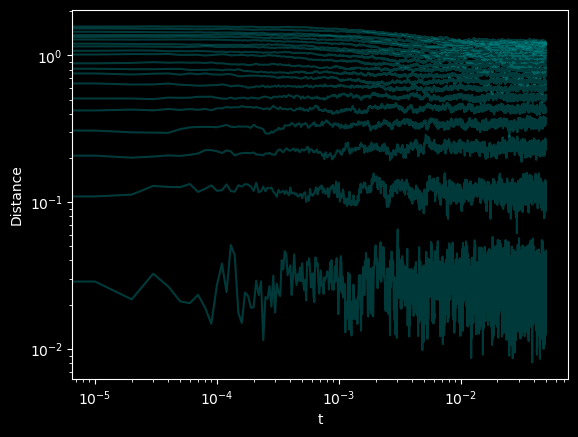

In [23]:
clipdistances_0, clipdistances_f, clipdistances_std, clippedensemble = distance_difference(k_BT_hs, num_particles=ensemble.N, clip_force=50)
# plt.semilogx()
# plt.errorbar(k_BT_hs, distances_f-distances_0, yerr=distances_std, fmt='o')
# plt.errorbar(k_BT_hs, clipdistances_f-clipdistances_0, yerr=clipdistances_std, fmt='o')

<ErrorbarContainer object of 3 artists>

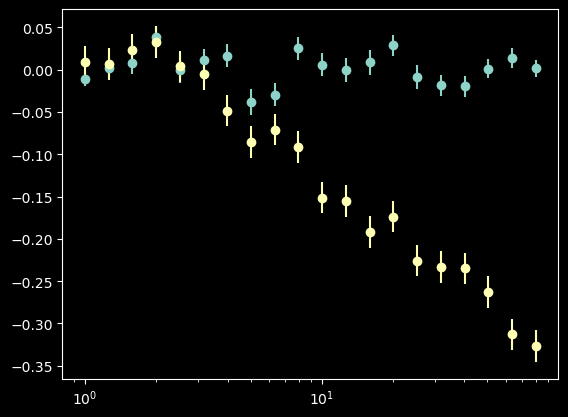

In [27]:
plt.semilogx()
plt.errorbar(k_BT_hs, distances_f-distances_0, yerr=distances_std, fmt='o')
plt.errorbar(k_BT_hs, clipdistances_f-clipdistances_0, yerr=(distances_f-distances_0).std(), fmt='o')

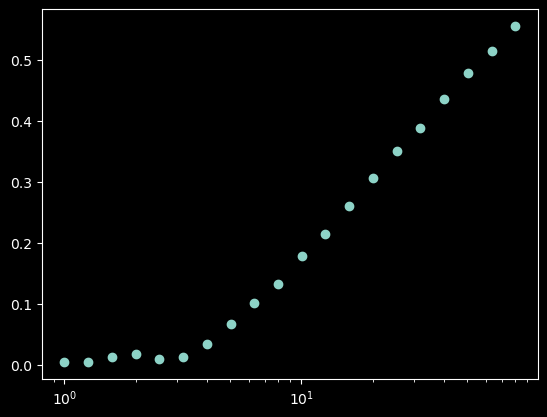

In [28]:
def compare_histograms(ensemble1, ensemble2):
    bins1, heights1 = ensemble1.get_histograms(x_max=potential.x_max, x_min=potential.x_min, regenerate=True, histogram_function=mpemba.slow_histogram)
    bins2, heights2 = ensemble2.get_histograms(x_max=potential.x_max, x_min=potential.x_min, regenerate=True, histogram_function=mpemba.slow_histogram)
    pdf1 = heights1[...,:-1000].mean(axis=2)
    pdf2 = heights2[...,:-1000].mean(axis=2)
    distances = mpemba.distance_functions.L1(pdf1, pdf2, bins1[1]-bins1[0], axis=1)
    return bins1, pdf1, pdf2, distances
bins1, pdf1, pdf2, distances = compare_histograms(ensemble, clippedensemble)

# plt.plot(bins1, pdf1[0,:])
# plt.plot(bins1, pdf2[0,:]) 
plt.semilogx()
plt.scatter(ensemble.temperatures, distances)  

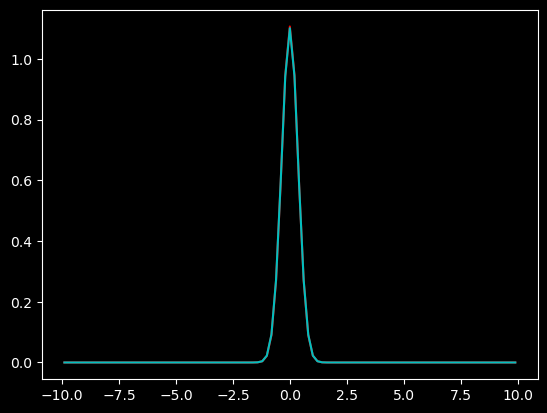

In [30]:
plt.plot(bins1, pdf1[1,:], 'r')
plt.plot(bins1, pdf2[1,:], 'c') 

In [ ]:
new_potential = mpemba.special_potentials.AsymmetricDoubleWellPotential(E_tilt=0.4, x_min=-5, x_max=10, force_asymmetry=0.5)
mass_in_box = []
for k_BT_h in k_BT_hs:
    mass_in_box.append(potential.mass_in_box(k_BT_h))
plt.loglog()
plt.scatter(k_BT_hs, mass_in_box)

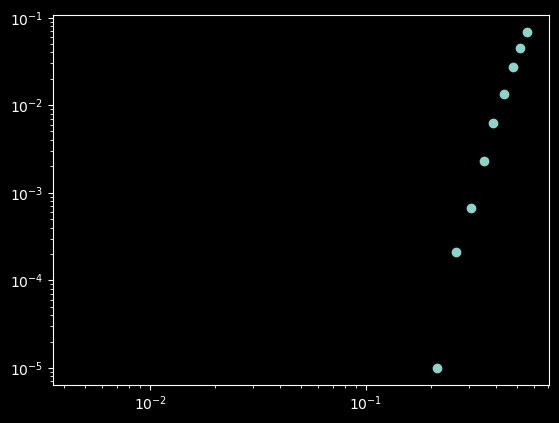

In [53]:
plt.loglog()
plt.scatter(distances, np.array(clip_fractions))

In [55]:
df = pd.DataFrame(np.array([clip_fractions, distances_0-distances_f, distances_std, clipdistances_0-clipdistances_f, clipdistances_std, distances]).T, columns=['clipfraction', 'noclip', 'noclipstd', 'clip', 'clipstd', 'L1'], index=k_BT_hs)
df.index.name = "T"
df.to_csv("clip_errors_harmonic_5000.csv")

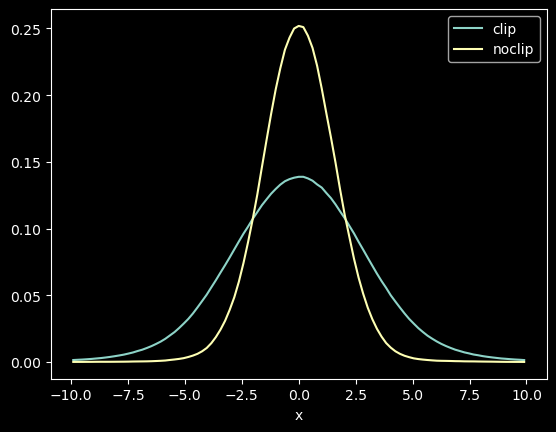

In [59]:
df = pd.DataFrame(np.array([pdf1[-1,:], pdf2[-1,:]]).T, columns=['clip', 'noclip'], index=bins1)
df.index.name = "x"
df.plot()
df.to_csv("clip_pdfs_harmonic_5000.csv")

In [ ]:
potential = mpemba.special_potentials.AsymmetricDoubleWellPotential(E_tilt=0.4, x_min=-5, x_max=5, force_asymmetry=0.5)
# from mpemba.py
x_vals = potential.mesh(100_000)
pi_h = potential.boltzmann(x_vals, 22)
x_sampled = np.random.choice(x_vals, 10_000_000, p=pi_h/np.sum(pi_h))
F_sampled = potential.F(x_sampled)
bins = np.linspace(-60, 60, 200)
plt.hist(F_sampled, bins=bins, density=True)
plt.xlabel(r"$F$")
plt.ylabel(r"$\pi_{\mathrm{force}}^{\mathrm{emp}}(F; T_h)$")

In [ ]:
eta = np.random.normal(0,1, size=F_sampled.shape)*np.sqrt(2*(22-1)/150)
noise_force_sampled = F_sampled + eta
plt.hist(noise_force_sampled, bins=100, density=True)
((np.abs(noise_force_sampled) > 50).sum())/len(noise_force_sampled)
plt.xlabel(r"$F$")
plt.ylabel(r"$\pi_{\mathrm{force}}^{\mathrm{emp}}(F; T_h)*N[0,\sqrt{\gamma k_BT_c(T_h/T_c-1)}]$")

In [ ]:
((np.abs(noise_force_sampled) > 50).sum())/len(noise_force_sampled) # Clip fraction

In [ ]:
import sympy as sym
potential =  mpemba.special_potentials.AsymmetricDoubleWellPotential(E_tilt=0.4, x_min=-5, x_max=5, force_asymmetry=0.5)
F_0 = potential.F_0

x = sym.symbols('x')
dF_0dx = sym.lambdify(x, sym.diff(F_0(x), x))

def get_coeffs(func, x_vals = np.array([-1,-0.5,0.5, 1])):
    # Evaluate polynomial at n+1 points and get the coefficients from that
    y_vals = func(x_vals)
    M = np.array([[x_val**i for i in range(len(x_vals))] for x_val in x_vals])
    M_inv = np.linalg.inv(M)
    return M_inv @ y_vals
def solver(F, cache = None):
    if cache is None:
        cache = get_coeffs(lambda x: F_0(x))[::-1] # solve for F = 0
    coeffs = np.copy(cache)
    coeffs[-1] = coeffs[-1] - F # Save work by only replacing the constant coeff
    roots = np.roots(coeffs) # Find the roots of the cubic
    outs = []
    for root in roots:
        if np.isclose(np.imag(root), 0, 1e-9):
            outs.append(np.real(root))
        else:
            outs.append(np.nan)
    return outs

F_vals = np.linspace(-potential.F_left, potential.F_right, 100)
principle_value, secondary_value, tertiary_value = [], [], []
print(get_coeffs(lambda x: F_0(x))[::-1])
for F_val in F_vals:
    outs = solver(F_val, cache=get_coeffs(lambda x: F_0(x))[::-1])
    principle_value.append(outs[0])
    secondary_value.append(outs[1])
    tertiary_value.append(outs[2])


principle_value, secondary_value, tertiary_value = np.array(principle_value), np.array(secondary_value), np.array(tertiary_value)
# principle_value
plt.scatter(F_vals, principle_value)
plt.scatter(F_vals, secondary_value)
plt.scatter(F_vals, tertiary_value)
plt.xlabel("F"); plt.ylabel(r"$x^*$")
# plt.plot(F_vals,F_0(principle_value))

In [ ]:
def integral_out(F, F_left = -potential.F_left, F_right=potential.F_right, k_BT_h=1):
    if F <= F_left:
        return 0
    if F >= F_right:
        return 0
    roots = solver(F)
    s = 0
    for root in roots:
        if not np.isnan(root):
            s += potential.boltzmann(root, k_BT_h)/np.abs(dF_0dx(root))
    return s

Fs = np.linspace(-potential.F_left-10, potential.F_left+10, 20000)
dF = Fs[1]-Fs[0]
pi_force = np.array([integral_out(F_val, k_BT_h=22) for F_val in Fs])

In [ ]:
plt.plot(Fs, pi_force)
plt.ylim((-0.01,0.5))
plt.xlabel("F")
plt.ylabel(r"$\pi_{force}(F, T_h)$")

In [ ]:
k_BT_h = 22
gamma = 1/150
normal_distro = lambda mu_F: np.sqrt(1/(2*np.pi*gamma*k_BT_h))*np.exp(-(((Fs-mu_F)**2)/(2*gamma*k_BT_h)))
normal_force = normal_distro(0)
# N[0, sqrt(gamma*(k_BT_h-k_BT_c))]
plt.plot(Fs, normal_force)
plt.xlabel("F")
plt.ylabel(r"$N[0,\sqrt{\gamma k_BT_c(T_h/T_c-1)}]$")

In [ ]:
np.array(pi_force).sum()*dF+Pi_l+Pi_r # Check normalisation

In [ ]:
Pi_r = scipy.integrate.quad(lambda x: potential.boltzmann(x, 22), *(potential.x_r, np.inf))[0]
Pi_l = scipy.integrate.quad(lambda x: potential.boltzmann(x, 22), *(-np.inf, potential.x_l))[0]
print(Pi_l, Pi_r)

force_distro = np.convolve(pi_force, normal_force, 'same')*(Fs[1]-Fs[0]) + Pi_l*normal_distro(-potential.F_left) + Pi_r*normal_distro(potential.F_right)

plt.plot(Fs, force_distro)
clip_left = force_distro[Fs>=potential.F_left].sum()*dF
clip_right = force_distro[Fs<=-potential.F_left].sum()*dF
Z = force_distro.sum()*dF
print(Z) # should be close to 1

print("Clip fraction: ", (clip_left+clip_right)/Z)
plt.xlabel(r"$F$")
plt.ylabel(r"$\pi_{\mathrm{force}}(F; T_h)*N\left[0,\sqrt{\gamma k_BT_c(T_h/T_c-1)}\right]$")

In [ ]:
Fs[np.isclose(Fs,-50, 7e-5)]

In [ ]:
force_distro_clip = np.where((Fs>=-50)&(Fs<=50), force_distro, np.zeros_like(force_distro))
position_distro = np.convolve(force_distro_clip+scipy.signal.unit_impulse(force_distro.shape, idx=np.where(np.isclose(Fs, -50, 7e-5))), scipy.signal.unit_impulse(force_distro.shape))


In [ ]:
pi_force_df = pd.DataFrame(np.array([Fs, pi_force]).T, columns=['F','pi'])
# pi_force_df.to_csv("pi_force.csv", index=None)

In [ ]:
# mesh = np.linspace(potential.x_l, potential.x_r, 1000)
# F_vals = F_0(mesh)

# func = lambda x: potential.boltzmann(x, 1)/np.abs(dF_0dx(x))

# outs = []
# for F_val in F_vals:
#     x_vals = mesh[F_0(mesh)==F_val]
#     func_vals = func(x_vals)
#     outs.append(func_vals)
# outs = np.array(outs)
# F_sort = F_vals[np.argsort(F_vals)]
# outs_sort = outs[np.argsort(F_vals)]
# plt.scatter(F_sort, outs_sort, marker=".")
# plt.ylim((-0.1, 1))

In [ ]:
# F_sort